In [82]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [83]:
from daemon_analysis_tools.file_handling import load_and_process_csv
from daemon_analysis_tools.data.utils import group_questions_by_journal
from daemon_analysis_tools.data.publisher import Publisher
from daemon_analysis_tools.file_handling import save_answers_to_yaml, load_answers_from_yaml

Load and process data:
- Group answers by publisher and journal, trying to uniform names written in slightly different ways.
- Store in a DataFrame

In [84]:
grouped_questions = load_answers_from_yaml('../../data/processed/all_answers')

MDPI/polymers/code_linting has inconsistencies: skipped


In [85]:
inconsitencies_dict = {}

tags_lookup = {"language understanding" : "Comprehension",
               "Language understanding" : "Comprehension",
               "difficulty in matching information and question" : "Comprehension",
               "Difficulty in matching information and question" : "Comprehension",
               "Selected answer is better interpretation of RDP." : "Comprehension",
               "Text missing and language understanding" : "Comprehension",
               "Text missing and Language understanding" : "Comprehension",
               "Text missing and  language understanding" : "Comprehension",
               "Text not found" : "Missed text",
               "Missed text." : "Missed text",
               "Text missing" : "Missed text",
               "Formatting inconsistent" : "Formatting",
               "Same answer but different wording." : "Formatting",
               "Inconsistent formatting." : "Formatting",}

for publisher, journals in grouped_questions.items():
    n_question = 0
    inconsitencies = {"Consistent": 0}

    for journal, data in journals.items():
        for question, answer in data.items():
            n_question += 1

            if answer.has_discrepancies():
                discrepancy_reason = answer.discrepancy_reason

                if discrepancy_reason in tags_lookup:
                    discrepancy_reason = tags_lookup[discrepancy_reason] 

                if not discrepancy_reason in inconsitencies:
                    inconsitencies[discrepancy_reason] = 0
                
                inconsitencies[discrepancy_reason] += 1
            else:
                inconsitencies["Consistent"] += 1
    
    print(publisher, inconsitencies)
    inconsitencies_dict[publisher] = inconsitencies

ACS {'Consistent': 225, 'Missed text': 57, 'Comprehension': 11, 'Formatting': 11}
AIP {'Consistent': 266}
APS {'Consistent': 205, 'Comprehension': 4}
Bentham Science {'Consistent': 72, 'Comprehension': 18, 'Missed text': 6, 'Formatting': 18}
Elsevier {'Consistent': 151, 'Missed text': 11, 'Comprehension': 16, 'Formatting': 12}
Frontiers {'Consistent': 77, 'Comprehension': 56}
IEEE {'Consistent': 225, 'Missed text': 30, 'Formatting': 30}
IOP {'Consistent': 157, 'Comprehension': 14}
MDPI {'Consistent': 140, 'Comprehension': 114, 'Missed text': 30}
Optica {'Consistent': 151, 'Comprehension': 10, 'Formatting': 10}
Pleiades Publishing {'Consistent': 100, 'Comprehension': 31, 'Missed text': 27, 'Formatting': 13}
RSC {'Consistent': 105, 'Comprehension': 25, 'Missed text': 41}
Springer Nature {'Consistent': 131, 'Missed text': 50, 'Formatting': 8, 'Rejected insider information': 1}
Taylor & Francis {'Consistent': 253, 'Comprehension': 32}
Wiley {'Consistent': 118, 'Missed text': 75, 'Comprehen

Get a `dict` labeled by publisher names of `dict`s labeled by journal names of `dict`s of `Question` instances. The `.answer` attribute contains the answers given by the respondents and the explanations text to motivate it.

[236  57  11] ['Consistent', 'Missed text', 'Comprehension']
[266] ['Consistent']
[205   4] ['Consistent', 'Comprehension']
[90 18  6] ['Consistent', 'Comprehension', 'Missed text']
[163  11  16] ['Consistent', 'Missed text', 'Comprehension']
[77 56] ['Consistent', 'Comprehension']
[255  30] ['Consistent', 'Missed text']
[157  14] ['Consistent', 'Comprehension']
[140 114  30] ['Consistent', 'Comprehension', 'Missed text']
[161  10] ['Consistent', 'Comprehension']
[113  31  27] ['Consistent', 'Comprehension', 'Missed text']
[105  25  41] ['Consistent', 'Comprehension', 'Missed text']
[139  50   1] ['Consistent', 'Missed text', 'Rejected insider information']
[253  32] ['Consistent', 'Comprehension']
[118  75  92] ['Consistent', 'Missed text', 'Comprehension']


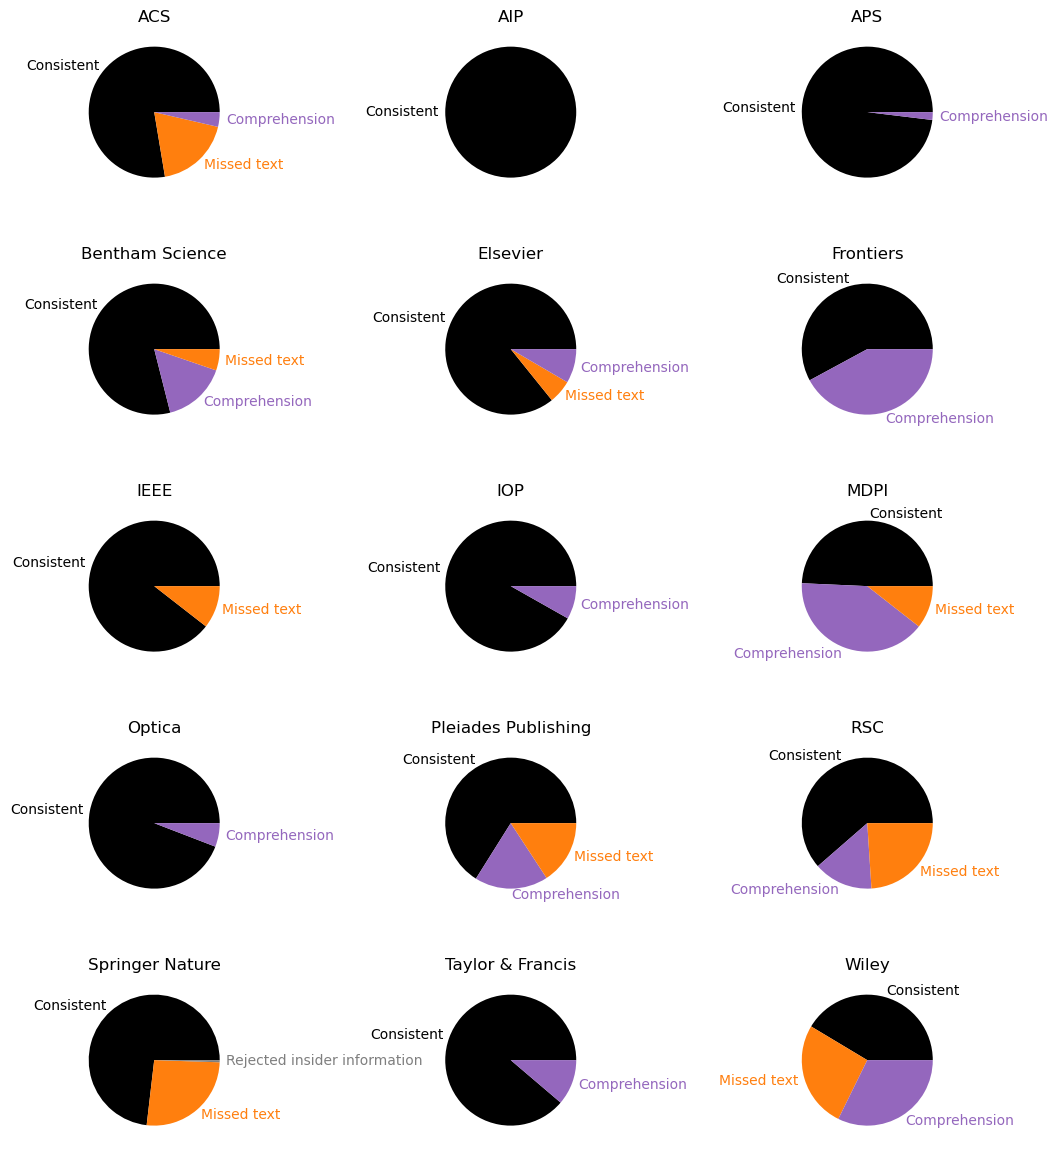

In [86]:
import numpy as np
from copy import deepcopy
from matplotlib import pyplot as plt

color_dict = {"Consistent" : "k",
          "Missed text" : "C1",
          "Comprehension" : "C4",
          "Rejected insider information" : "C7",

}

fig = plt.figure(figsize=(10, 12))

for ind, (publisher, data_0) in enumerate(inconsitencies_dict.items()):
    data = deepcopy(data_0)

    if "Formatting" in data:
        data["Consistent"] += data["Formatting"]
        data.pop("Formatting", None)

    y = np.array(list(data.values()))
    labels = list(data.keys())

    print(y, labels)

    w = 3
    h = int(np.ceil(len(inconsitencies_dict)/w))

    colors = []
    for l in labels:
        colors.append(color_dict[l])

    plt.subplot(h, w, ind+1)
    plt.title(publisher)
    _, texts = plt.pie(y, labels=labels, colors=colors)

    for text, color in zip(texts, colors):
        text.set_color(color)

plt.tight_layout()
fig.savefig("../../data/processed/inconsistencies.pdf")